---
## Ejercicio 2 — Normalizing Flow con `zuko` y `MAF`

En este ejercicio vas a ajustar un **Masked Autoregressive Flow (MAF)** usando `zuko` sobre un patrón bidimensional de dos medias lunas. El objetivo es que la idea de modelar densidades exactas se vea de forma geométrica y con una implementación compacta.

1. Generar un dataset 2D cuya densidad de probabilidad conste de tres densidades gaussianas centradas en distintos valores medios y con distintos anchos. Puede modificar la densidad de probabilidad para simplificar/complicar la distribución objetivo si lo desea.
2. Graficar la nube real para inspeccionar su forma.
3. Instanciar un flow con `zuko.flows.MAF(features=2, ...)`.
4. Entrenarlo por máxima verosimilitud, minimizandoel negativo de la log verosimilitud `-flow().log_prob(x)`.
5. Muestrear del modelo entrenado con `flow().sample((n,))` y comparar nube real vs nube generada.
6. Repetir el ejercicio con un RealNVP y comparar resultado respecto a MAF.

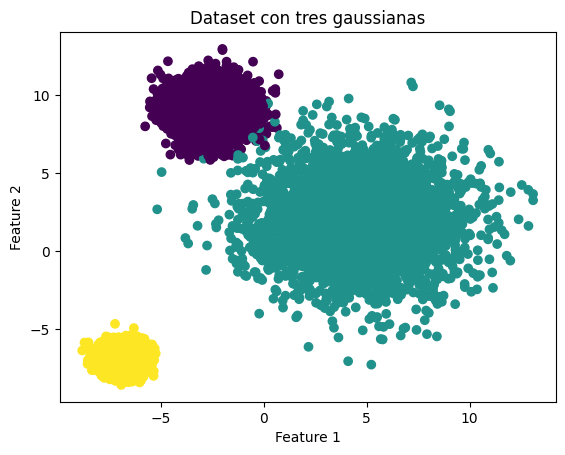

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# Generar un dataset 2D con tres gaussianas con diferentes medias y covarianzas. Visualizar el dataset.
X, y = make_blobs(n_samples=10000, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Dataset con tres gaussianas')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


In [26]:
import zuko
# Crear un modelo MAF
#Instanciar un flow
flow = zuko.flows.MAF(features=2, transforms=5, hidden_features=[64, 64])

In [27]:
import torch
train_data = torch.from_numpy(X).float()

def train_zuko_flow(flow, data, epochs=100, batch_size=128):
    optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)
    for epoch in range(epochs):
        indices = np.random.permutation(len(data))
        data_shuffled = data[indices]
        for i in range(0, len(data_shuffled), batch_size):
            batch = data_shuffled[i:i+batch_size]
            loss = -flow().log_prob(batch).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

train_zuko_flow(flow, train_data, epochs=500, batch_size=32)

Epoch 10/500, Loss: 4.0587
Epoch 20/500, Loss: 4.2160
Epoch 30/500, Loss: 4.4349
Epoch 40/500, Loss: 4.6397
Epoch 50/500, Loss: 4.6065
Epoch 60/500, Loss: 4.0742
Epoch 70/500, Loss: 4.7615
Epoch 80/500, Loss: 4.4397
Epoch 90/500, Loss: 5.3115
Epoch 100/500, Loss: 3.8858
Epoch 110/500, Loss: 3.6201
Epoch 120/500, Loss: 3.8047
Epoch 130/500, Loss: 3.8389
Epoch 140/500, Loss: 3.9558
Epoch 150/500, Loss: 4.3458
Epoch 160/500, Loss: 4.1398
Epoch 170/500, Loss: 3.9717
Epoch 180/500, Loss: 4.1559
Epoch 190/500, Loss: 3.5277
Epoch 200/500, Loss: 4.3786
Epoch 210/500, Loss: 3.8469
Epoch 220/500, Loss: 4.2231
Epoch 230/500, Loss: 4.4251
Epoch 240/500, Loss: 4.4636
Epoch 250/500, Loss: 4.6829
Epoch 260/500, Loss: 3.7057
Epoch 270/500, Loss: 4.0524
Epoch 280/500, Loss: 3.9399
Epoch 290/500, Loss: 3.6588
Epoch 300/500, Loss: 3.6841
Epoch 310/500, Loss: 3.3431
Epoch 320/500, Loss: 4.3996
Epoch 330/500, Loss: 3.9265
Epoch 340/500, Loss: 4.6329
Epoch 350/500, Loss: 3.8251
Epoch 360/500, Loss: 4.0647
E

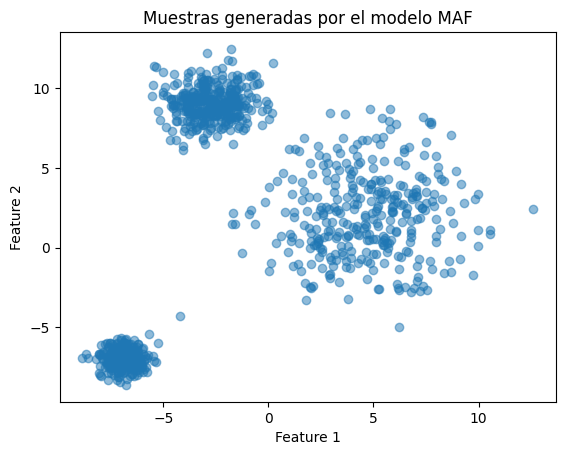

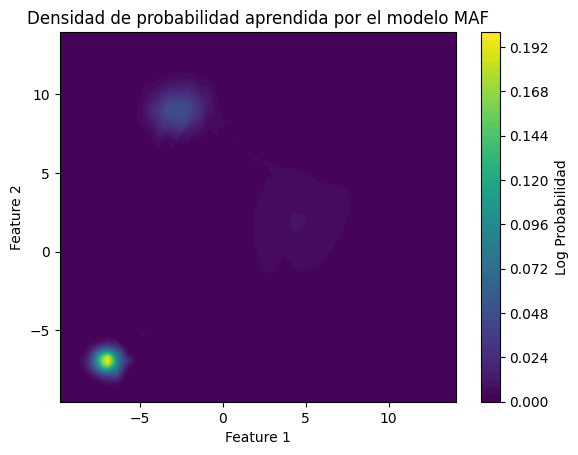

In [28]:
#Muestrear del modelo entrenado y visualizar las muestras generadas.
with torch.no_grad():
    samples = flow().sample((1000,)).numpy()
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.title('Muestras generadas por el modelo MAF')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
#Mostrar distribución de probabilidad aprendida por el modelo. Para esto, crear una malla de puntos en el espacio 2D y evaluar la densidad de probabilidad en cada punto. Visualizar la densidad utilizando un mapa de calor o un gráfico de contorno.
x = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
y = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid_points = torch.from_numpy(np.column_stack([X_grid.ravel(), Y_grid.ravel()])).float()
with torch.no_grad():
    log_probs = flow().log_prob(grid_points).numpy()
    prob = np.exp(log_probs).reshape(X_grid.shape)
Z = prob.reshape(X_grid.shape)
plt.contourf(X_grid, Y_grid, Z, levels=50, cmap='viridis')
plt.title('Densidad de probabilidad aprendida por el modelo MAF')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Log Probabilidad')
plt.show()

In [ ]:
# Entrenar y comparar un RealNVP contra la MAF
import zuko
import matplotlib.pyplot as plt
import torch

realnvp_flow = zuko.flows.RealNVP(features=2, transforms=5, hidden_features=[64, 64])
train_zuko_flow(realnvp_flow, train_data, epochs=500, batch_size=32)



Epoch 10/500, Loss: 4.5758
Epoch 20/500, Loss: 4.6278
Epoch 30/500, Loss: 3.8383
Epoch 40/500, Loss: 4.7140
Epoch 50/500, Loss: 4.3918
Epoch 60/500, Loss: 5.0858
Epoch 70/500, Loss: 4.3653
Epoch 80/500, Loss: 4.7086
Epoch 90/500, Loss: 3.7202
Epoch 100/500, Loss: 4.2078
Epoch 110/500, Loss: 3.6899
Epoch 120/500, Loss: 4.2718
Epoch 130/500, Loss: 4.4179
Epoch 140/500, Loss: 3.9729
Epoch 150/500, Loss: 4.6830
Epoch 160/500, Loss: 4.0928
Epoch 170/500, Loss: 3.9333


KeyboardInterrupt: 

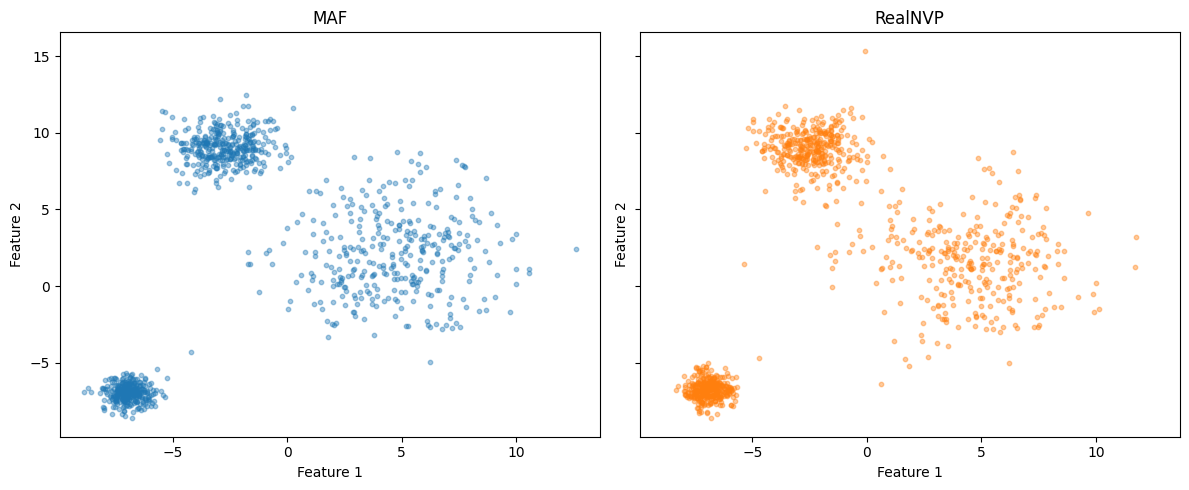

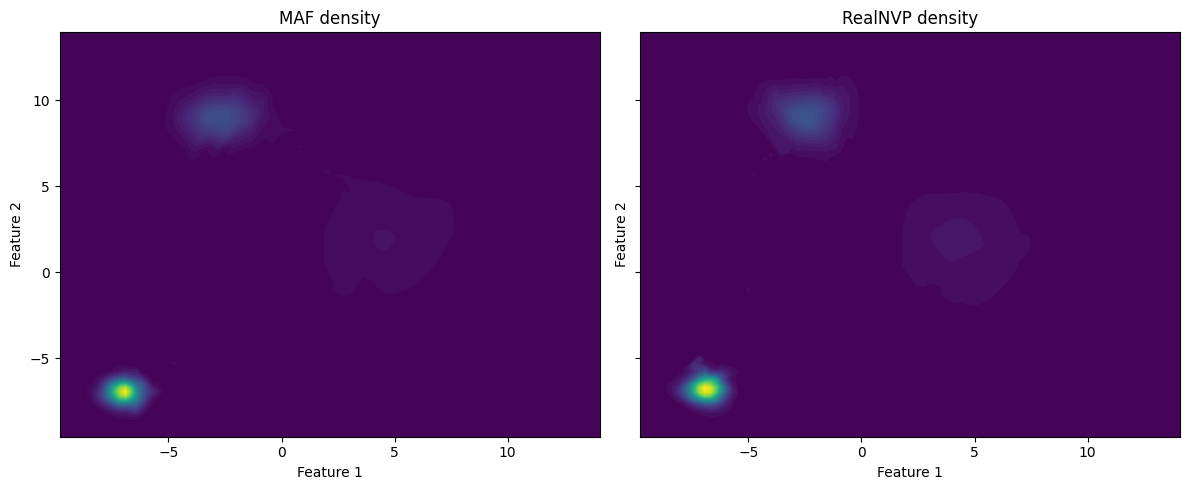

RealNVP entrenado y comparado contra la MAF con la misma rutina y el mismo dataset.


In [30]:
with torch.no_grad():
    maf_samples = flow().sample((1000,)).cpu().numpy()
    realnvp_samples = realnvp_flow().sample((1000,)).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(samples[:, 0], samples[:, 1], alpha=0.4, s=10)
axes[0].set_title('MAF')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(realnvp_samples[:, 0], realnvp_samples[:, 1], alpha=0.4, s=10, color='tab:orange')
axes[1].set_title('RealNVP')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Comparación rápida de densidades aprendidas sobre una grilla
with torch.no_grad():
    maf_log_probs = flow().log_prob(grid_points).cpu().numpy()
    realnvp_log_probs = realnvp_flow().log_prob(grid_points).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
maf_Z = np.exp(maf_log_probs).reshape(X_grid.shape)
rnvp_Z = np.exp(realnvp_log_probs).reshape(X_grid.shape)

cont0 = axes[0].contourf(X_grid, Y_grid, maf_Z, levels=50, cmap='viridis')
axes[0].set_title('MAF density')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

cont1 = axes[1].contourf(X_grid, Y_grid, rnvp_Z, levels=50, cmap='viridis')
axes[1].set_title('RealNVP density')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print('RealNVP entrenado y comparado contra la MAF con la misma rutina y el mismo dataset.')